In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, classification_report

In [3]:
from sklearn.metrics import confusion_matrix

In [4]:
df = pd.read_csv("HR_Employee_Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.shape

(1470, 35)

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [11]:
df.drop(columns=["EmployeeCount","StandardHours","Over18"],inplace=True)

In [12]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [13]:
df.select_dtypes(include='object').columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

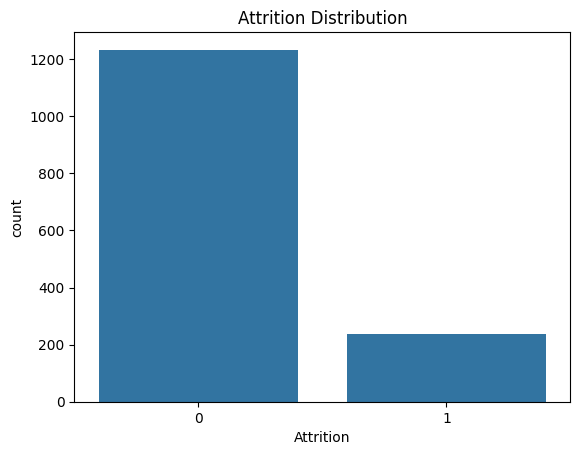

In [14]:
sns.countplot(x="Attrition",data=df)
plt.title("Attrition Distribution")
plt.savefig("attrition_distribution.png")
plt.show()

More employees stay than leave

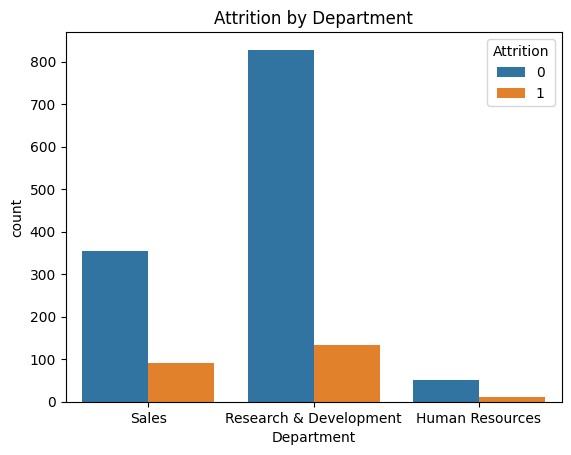

In [15]:
sns.countplot(x="Department",hue="Attrition",data=df)
plt.title("Attrition by Department")
plt.savefig("attrition_by_department.png")
plt.show()

Research and Development tends highest to be more stable than of Sales and HR

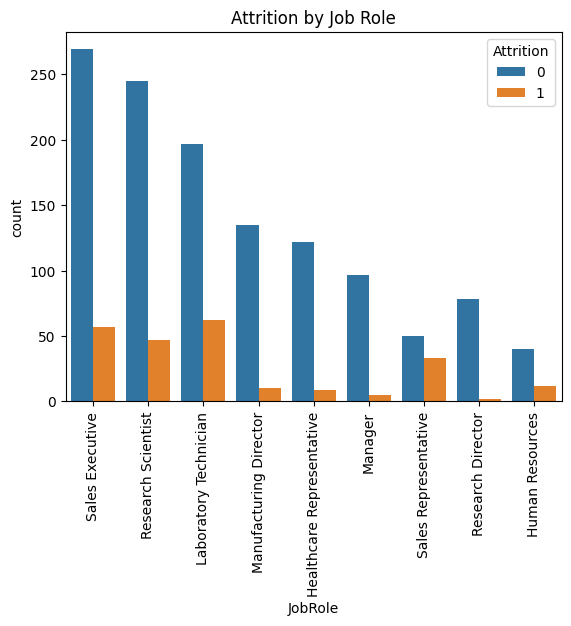

In [16]:
sns.countplot(x="JobRole",hue="Attrition",data=df)
plt.title("Attrition by Job Role")
plt.xticks(rotation=90)
plt.savefig("Attrition_by_Job_Role.png")
plt.show()

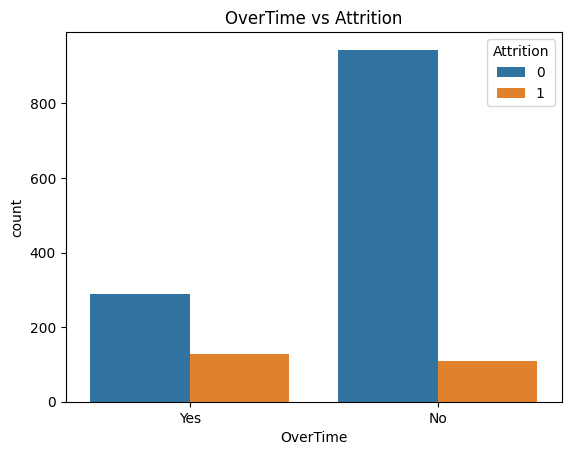

In [19]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("OverTime vs Attrition")
plt.savefig("OverTime_Attrition.png")
plt.show()

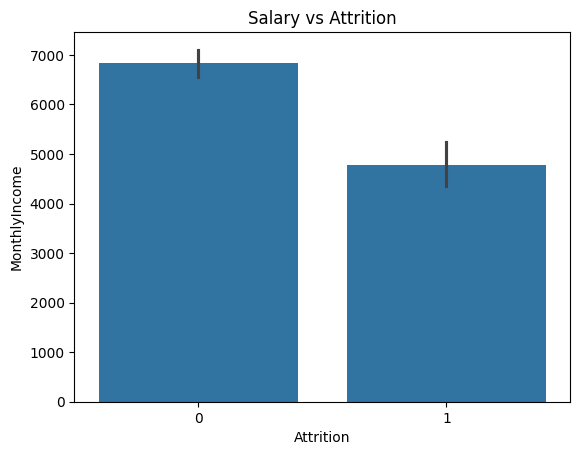

In [20]:
sns.barplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Salary vs Attrition")
plt.savefig("Salary_vs_Attrition.png")

plt.show()

Lower salary :-  higher attrition

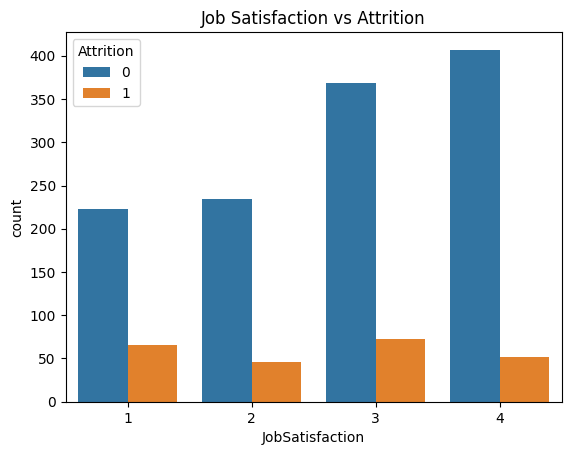

In [21]:
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title("Job Satisfaction vs Attrition")
plt.savefig("Job_Satisfaction_vs_Attrition")
plt.show()

Low satisfaction :- more employees leave

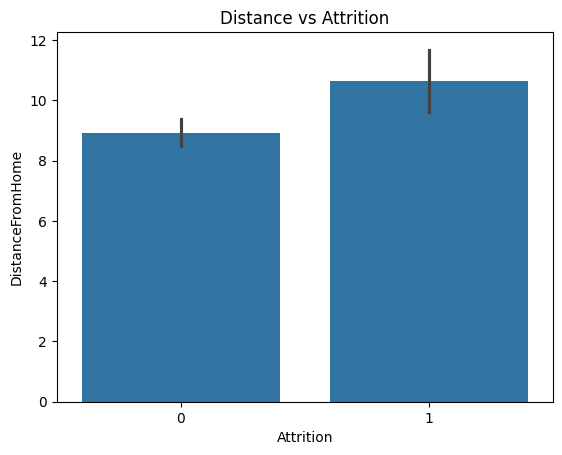

In [22]:
sns.barplot(x='Attrition', y='DistanceFromHome', data=df)
plt.title("Distance vs Attrition")
plt.savefig("Distance_vs_Attrition")
plt.show()

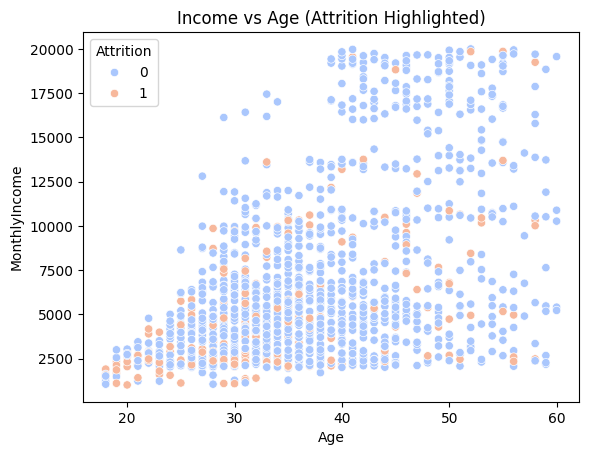

In [23]:
sns.scatterplot(x='Age', y='MonthlyIncome', hue='Attrition', data=df, palette='coolwarm')
plt.title("Income vs Age (Attrition Highlighted)")
plt.savefig("Income_vs_Age.png")
plt.show()

Low income younger :- more attrition

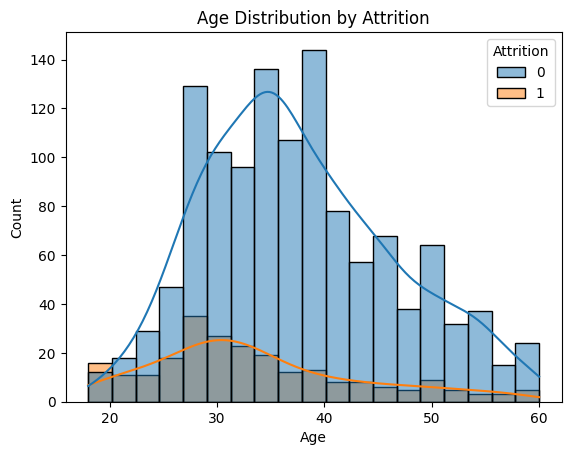

In [24]:
sns.histplot(data=df, x='Age', hue='Attrition', kde=True)
plt.title("Age Distribution by Attrition")
plt.savefig("Age_Distribution_by_Attrition.png")
plt.show()

Younger employees :- Higher attrition

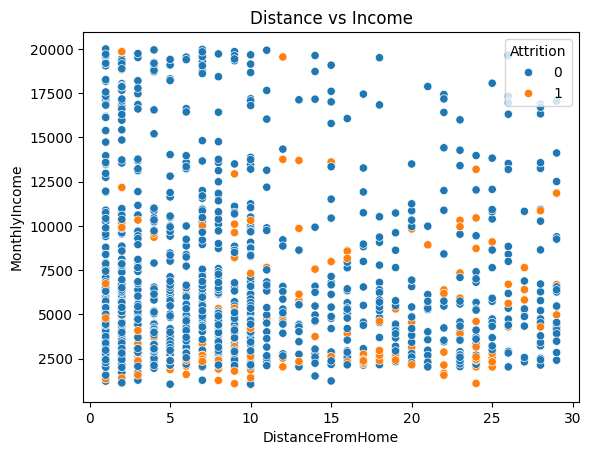

In [25]:
sns.scatterplot(x='DistanceFromHome', y='MonthlyIncome', hue='Attrition', data=df)
plt.title("Distance vs Income")
plt.show()

# Encoding :- converting categorical data into numbers

In [26]:
df = pd.get_dummies(df, drop_first=True)

# Train Test Split

In [27]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [29]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("🔹 Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

🔹 Logistic Regression
Accuracy: 0.8843537414965986
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       255
           1       0.58      0.46      0.51        39

    accuracy                           0.88       294
   macro avg       0.75      0.71      0.72       294
weighted avg       0.88      0.88      0.88       294



# Decision Tree

In [30]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("\n🔹 Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


🔹 Decision Tree
Accuracy: 0.8197278911564626
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       255
           1       0.23      0.15      0.18        39

    accuracy                           0.82       294
   macro avg       0.55      0.54      0.54       294
weighted avg       0.79      0.82      0.80       294



# Random Forest

In [31]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n🔹 Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


🔹 Random Forest
Accuracy: 0.8775510204081632
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



# Logistic Regression ROC Curve

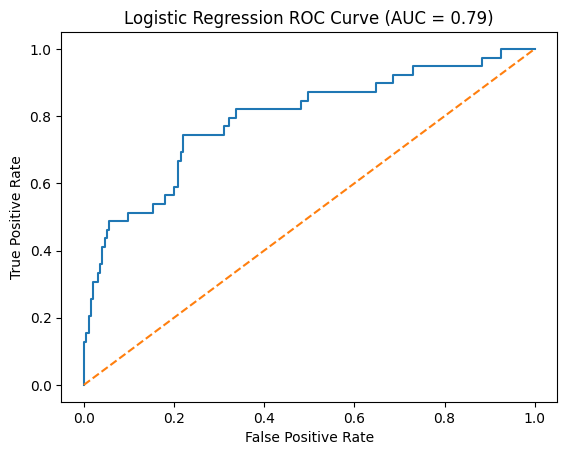

In [32]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure()
plt.plot(fpr_lr, tpr_lr)
plt.plot([0,1], [0,1], '--')
plt.title(f"Logistic Regression ROC Curve (AUC = {auc_lr:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


## Comment:
## Logistic Regression provides a baseline model.
## It captures linear relationships and gives moderate ROC performance.

# Decision Tree ROC Curve

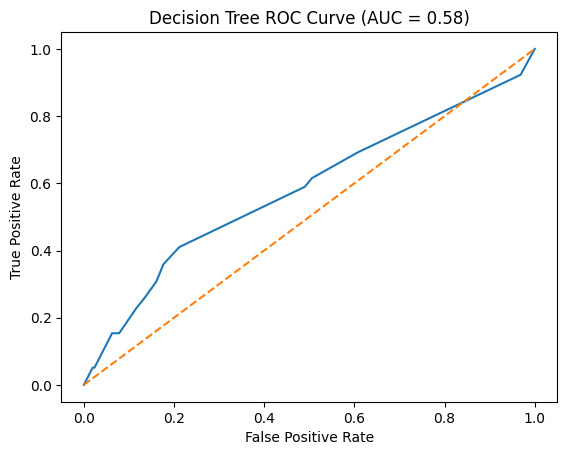

In [33]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_prob_dt = dt.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure()
plt.plot(fpr_dt, tpr_dt)
plt.plot([0,1], [0,1], '--')
plt.title(f"Decision Tree ROC Curve (AUC = {auc_dt:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Comment:
# Decision Tree captures non-linear patterns in the data.
# However, it may overfit, leading to slightly unstable ROC performance.

# Random Forest ROC Curve

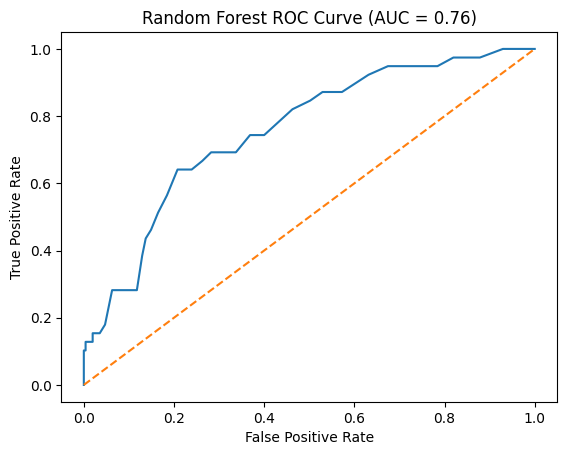

In [36]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf)
plt.plot([0,1], [0,1], '--')
plt.title(f"Random Forest ROC Curve (AUC = {auc_rf:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Comment:
# Random Forest provides the best performance among the models.
# It reduces overfitting and achieves a higher AUC, indicating better classification ability.

## Model evaluation

## Use confusion matrix–based accuracy to choose the best model

In [37]:
# 🤖 Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
acc_lr = (cm_lr[0][0] + cm_lr[1][1]) / cm_lr.sum()
print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.8843537414965986


In [38]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
acc_dt = (cm_dt[0][0] + cm_dt[1][1]) / cm_dt.sum()
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.8197278911564626


In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
acc_rf = (cm_rf[0][0] + cm_rf[1][1]) / cm_rf.sum()
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.8775510204081632


# Final Model Selection
# Selected Model: Logistic Regression

Because:

Highest accuracy (88.44%)
More stable and less overfitting
Simpler and easier to interpret


| Model               | Accuracy     |
| ------------------- | ------------ |
| Logistic Regression | 88.44% |
| Decision Tree       | 81.97%       |
| Random Forest       | 87.76%       |

